In [29]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [3]:
from matplotlib import pyplot as plt
import numpy as np
from pathlib import Path
import sys
import tifffile as tf
import torch
from typing import List, Tuple
import os
import pandas as pd
import plotly.express as px
sys.path.append('..')
from neurotrack.data import neuron_data
from neurotrack.data import DrawingComplexityConfig
from data_prep import load, draw

In [5]:
complexity_config = DrawingComplexityConfig()
data_generator = neuron_data.DataGenerator(cache_dir="../training_dir", complexity_config=complexity_config)

In [ ]:
# data_generator.empty_cache()

Cache directory ../data_cache emptied.


In [162]:
swc_root = "/home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subsubset"
img_root = "/home/brysongray/data/neurotrack_data/gold166/gold166_tifs_processed"
# img_root = None
data_generator.generate_data(swc_dir=swc_root, img_dir=img_root, subtrees_per_swc=1, complexity_range=(0.0, 1.0), n_steps=6, morphology="any")

Processing 3 SWC files...
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subsubset/091201c1.swc
Adjusted file prefix to avoid duplicate: 091201c1_subtree_06
Processed 091201c1: 1 subtrees generated
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subsubset/080926a.swc
Adjusted file prefix to avoid duplicate: 080926a_subtree_06
Processed 080926a: 1 subtrees generated
loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subsubset/091202c2.swc
Adjusted file prefix to avoid duplicate: 091202c2_subtree_06
Processed 091202c2: 1 subtrees generated
Appended entry data to existing CSV: ../data_cache/generated_data_entries.csv

Processing complete!
Total subtrees generated: 3
Results saved to: ../data_cache


{'processed_files': 3, 'total_subtrees': 3, 'output_dir': '../data_cache'}

In [63]:
# Test sampling from the dataset
dataset = neuron_data.Dataset(data_generator.cache_dir)
for e in dataset.entries:
    print(e['neuron_name'])
print(dataset.get_complexity_distribution())

dataloader = neuron_data.DataLoader(dataset, complexity=1.0, morphology="any", stochastic_complexity=False)

NameError: name 'data_generator' is not defined

In [78]:
dataloader.set_complexity(0.6)
dataloader.weights

[0.0,
 0.0,
 0.0,
 0.16666666666666666,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.16666666666666666,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.16666666666666666,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.16666666666666666,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.16666666666666666,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.16666666666666666,
 0.0,
 0.0]

Sampled image path: ../training_dir/Cortex_2256-8.CNG_subtree_05_image.tif
Sampled complexity: 1.0


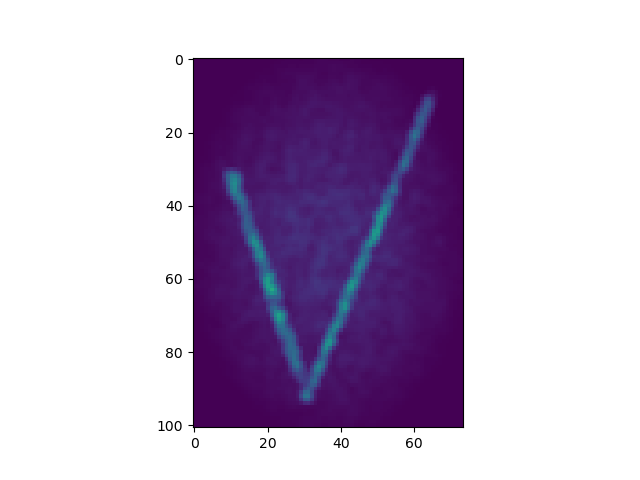

0.02432632
0.038230278


In [7]:
dataloader.set_complexity(1.0)
dataloader.set_morphology("any")

entry = dataloader.sample()
img_path = entry['img_path']

print(f"Sampled image path: {img_path}")
print(f"Sampled complexity: {entry['complexity']}")
img = tf.imread(img_path)

if img.dtype != np.float32:
    img = img.astype(np.float32) / img.max()

plt.close('all')
fig = plt.figure()
plt.imshow(img[0].max(axis=0), vmin=0, vmax=1)
plt.show()
print(img.mean())
print(img.std())

In [62]:
def draw_image_with_skeleton(img, swc_list, dim=0, seeds=None):

    i = 1 if dim == 0 else 2
    j = 1 if dim == 2 else 0

    sections, _ = load.parse_swc(swc_list, verbose=False, transpose=False)
    fig, ax = plt.subplots()
    
    ax.imshow(img[0].max(axis=dim), vmin=0, vmax=1)

    # Draw skeleton as 2D line segments by dropping z (index 0)
    for _, section_data in sections.items():
        for seg in section_data:
            p0, p1 = seg[0], seg[1]
            y0, x0 = float(p0[i]), float(p0[j])
            y1, x1 = float(p1[i]), float(p1[j])
            # Only draw if in crop (for cropped panel); full panel draws all
            ax.plot([x0, x1], [y0, y1], color='red', linewidth=1.0, alpha=0.8)
    
    if seeds is not None:
        ax.scatter(seeds[:, 0], seeds[:, 1], color='magenta', s=20, alpha=0.8)
    
    
    plt.show()


def get_seed(edge_list, id_to_idx, tree):
    """
    Get a seed point for the tree, which is the end point farthest from any branch points.

    Parameters
    ----------
    edge_list: dict
        Dictionary mapping node IDs to lists of connected node IDs.
    id_to_idx: dict
        Dictionary mapping node IDs to their indices in the tree tensor.
    tree: torch.tensor of shape (N, 7)
        Tensor representing the tree, where each row is a node and columns are [id, type, x, y, z, radius, parent id].

    Returns
    -------
    seeds: torch.tensor of shape (1, 3)
    """
    # seed is the end point farthest from any branch points.
    branch_nodes = [k for k, v in edge_list.items() if len(v) > 2]
    end_nodes = [k for k, v in edge_list.items() if len(v) == 1]
    
    branch_indices = [id_to_idx[int(n)] for n in branch_nodes]
    end_indices = [id_to_idx[int(n)] for n in end_nodes]
    
    branch_coords = tree[branch_indices, 2:5]  # shape (M,3)
    end_coords = tree[end_indices, 2:5]  # shape (N,3)

    if branch_coords.shape[0] == 0:
        # if no branch points, just use the first endpoint
        seeds = end_coords[0].unsqueeze(0)
    else:
        # Subsample branch points if there are too many
        # This approximates the "farthest from any branch" metric
        compare_coords = branch_coords
        if branch_coords.shape[0] > 30:
            indices = torch.randperm(branch_coords.shape[0], device=branch_coords.device)[:30]
            compare_coords = branch_coords[indices]

        # shape (N, 1, 3) - (1, M, 3) -> (N, M, 3) -> sum sq -> (N, M)
        dists_sq = torch.sum((end_coords.float().unsqueeze(1) - compare_coords.float().unsqueeze(0)) ** 2, dim=2)
        min_dists_sq, _ = torch.min(dists_sq, dim=1)  # shape (N,)
        farthest_end_idx = torch.argmax(min_dists_sq)
        seeds = end_coords[farthest_end_idx].unsqueeze(0)
    
    return seeds

In [61]:
plt.close('all')

dataloader.set_complexity(1.0)
dataloader.set_morphology("any")

# Define batch size and grid layout
batch_size = 6
cols = 3
rows = (batch_size + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()

for idx in range(batch_size):
    ax = axes[idx]
    
    # Sample data
    entry = dataloader.sample()
    swc_path = entry['swc_path']
    img_path = entry['img_path']

    # Load and normalize image
    img = tf.imread(img_path)
    if img.dtype != np.float32:
        img = img.astype(np.float32) / 255.0

    # Load SWC
    swc_list = load.swc(swc_path)
    swc_list = torch.tensor(swc_list)

    # Calculate seeds
    edge_list = load.undirected_edge_list(swc_list)
    id_to_idx = {int(node_id): idx for idx, node_id in enumerate(swc_list[:, 0].tolist())}
    seeds = get_seed(edge_list, id_to_idx, swc_list)

    # Plotting logic (inlined to support subplots)
    dim = 0
    i = 1 if dim == 0 else 2
    j = 1 if dim == 2 else 0

    sections, _ = load.parse_swc(swc_list, verbose=False, transpose=False)
    
    # Display max projection
    ax.imshow(img[0].max(axis=dim), vmin=0, vmax=1)

    # Draw skeleton
    for _, section_data in sections.items():
        for seg in section_data:
            p0, p1 = seg[0], seg[1]
            y0, x0 = float(p0[i]), float(p0[j])
            y1, x1 = float(p1[i]), float(p1[j])
            ax.plot([x0, x1], [y0, y1], color='red', linewidth=1.0, alpha=0.8)
    
    # Draw seeds
    if seeds is not None:
        ax.scatter(seeds[:, 0], seeds[:, 1], color='magenta', s=20, alpha=0.8)
        
    ax.set_title(f"Complexity: {entry['complexity']:.2f}")
    ax.axis('off')

for idx in range(batch_size, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

NameError: name 'dataloader' is not defined

In [3]:
rng = np.random.default_rng(0)
renderer = draw.NeuronRenderer(rng=rng)

config = draw.DrawingConfig(
    width = 4.0,
    random_width = False,   
    foreground_mean = 0.6,
    foreground_std = 0.3,
    background_mean = 0.4,
    background_std = 0.04,
    mask_threshold = 0.1,  # Fraction of max value for foreground/background mask
    spatial_noise_scale = 3.0,  # Scale for spatial noise features
    spatial_noise_amplitude = 1.0,  # Amplitude multiplier for spatial noise contribution
    noise_method = 'gaussian_convolution',  # Method for spatial noise: 'gaussian_convolution', 'fractal', 'sparse_kernel'
    blur = 0.8,  # Sigma for optional Gaussian smoothing applied during post-processing
    sharpness = 1.0,  # Sharpness parameter for line drawing edges
    vignette_magnitude = 0.0,  # Strength of vignette effect (0 disables)
    width_correlation = True,
    width_correlation_rho = 0.0,  # target lag-1 correlation for widths when enabled
    segment_intensity_correlation = True,
    segment_intensity_correlation_rho = 0.0 
)

swc_root = Path("/home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset")
swc_path = swc_root / next(swc_root.iterdir())
swc_list = load.swc(swc_path)

sections, _ = load.parse_swc(swc_list, verbose=False, transpose=False)

img = renderer.draw_neuron(sections, config)



loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/3_CL-I_MT_X_MYR-GFP_ddaE_MT-mCherry_membrane-GFP.swc


In [4]:
list(swc_root.iterdir())

[PosixPath('/home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subsubset/091201c1.swc'),
 PosixPath('/home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subsubset/080926a.swc'),
 PosixPath('/home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subsubset/091202c2.swc')]

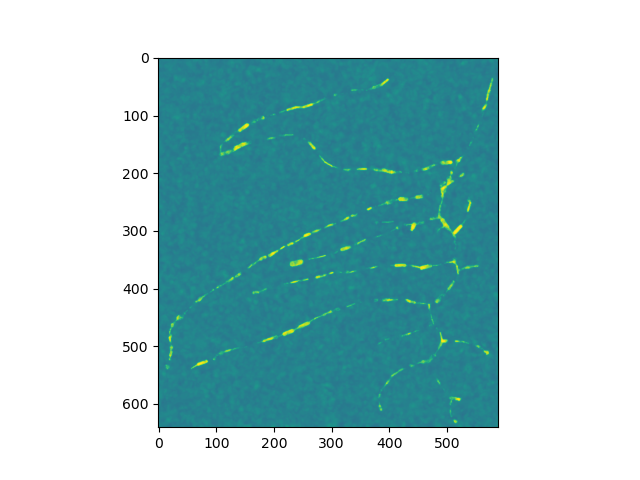

In [4]:
plt.close('all')
fig = plt.figure()
plt.imshow(img.data[0].amax(axis=2), vmin=0, vmax=1)
plt.show()

# Setup dataset for complex combination of mask and microscopy.

In [54]:
def extract_subtrees(swc_list, subtrees_per_swc=4):
    subtrees = []
    morphologies = []
    box_size = 200.0
    swc_array = np.array(swc_list)
    centers = swc_array[np.random.choice(np.arange(len(swc_array)), size=subtrees_per_swc, replace=False)]
    for center in centers:
        center_point = center[2:5]
        in_box_mask = np.all(
            (swc_array[:, 2:5] >= (center_point - box_size/2)) &
            (swc_array[:, 2:5] <= (center_point + box_size/2)),
            axis=1
        )
        subtree = swc_array[in_box_mask].tolist()
        subtree_edge_list = load.undirected_edge_list(subtree)
        # only keep tree connected to the center node
        center_node = center[0]
        visited = set()
        to_visit = [center_node]
        while to_visit:
            node = to_visit.pop()
            if node not in visited:
                visited.add(node)
                neighbors = subtree_edge_list.get(node, [])
                to_visit.extend(neighbors)
        subtree = [node for node in subtree if node[0] in visited]
        # get number of branches
        num_branches = sum(1 for neighbors in subtree_edge_list.values() if len(neighbors) > 2)
        morphology_ = "simple" if num_branches == 0 else "moderate" if num_branches == 1 else "complex"
        subtrees.append(subtree)
        morphologies.append(morphology_)
    return subtrees, morphologies


def crop_around_subtree(image: torch.Tensor, subtree: List, 
                        padding: int = 10) -> Tuple[torch.Tensor, List]:
    """
    Crop image around subtree coordinates and shift subtree coordinates.
    """
    # Get coordinates from subtree
    subtree_array = np.array(subtree)
    coords = subtree_array[:, 2:5]  # x, y, z columns
    
    # Calculate bounding box with padding
    min_coords = np.min(coords, axis=0) - padding
    max_coords = np.max(coords, axis=0) + padding
    
    # Convert to integers and ensure within bounds
    image_shape = image.shape
    min_coords = np.maximum(0, min_coords.astype(int))
    max_coords = np.minimum(image_shape[-3:][::-1], max_coords.astype(int))
    
    # Crop the image
    cropped_image = image[..., min_coords[2]:max_coords[2], 
                               min_coords[1]:max_coords[1], 
                               min_coords[0]:max_coords[0]]
    
    # Shift subtree coordinates
    shifted_subtree = []
    for node in subtree:
        shifted_node = (
            node[0],  # node_id
            node[1],  # node_type  
            node[2] - min_coords[0],  # x
            node[3] - min_coords[1],  # y
            node[4] - min_coords[2],  # z
            node[5],  # radius
            node[6]   # parent_id
        )
        shifted_subtree.append(shifted_node)
    
    return cropped_image, shifted_subtree


def pad_with_noise(cropped_image, subtree, pad=10):
    # pad after cropping
    # pad image with random noise based on image stats
    img_mean = float(torch.mean(cropped_image.float()))
    img_std = float(torch.std(cropped_image.float()))
    if img_std == 0.0:
        img_std = 1e-6

    device = cropped_image.device
    dtype = cropped_image.dtype

    # Compute padded shape (assumes cropped_image shape is [C, Z, Y, X])
    padded_shape = torch.tensor(cropped_image.shape)
    padded_shape[-3:] += torch.tensor((2*pad,)*3)

    # Create noise in float on the correct device, clamp and cast once
    noise = torch.normal(mean=img_mean, std=img_std, size=tuple(padded_shape), device=device)
    if dtype == torch.uint8:
        noise = noise.clamp(0, 255).to(dtype)
    else:
        noise = noise.clamp(0.0, 1.0).to(dtype)

    # Copy original image into the center of the noisy padded tensor (in-place)
    z0, y0, x0 = pad, pad, pad
    zdim, ydim, xdim = (0,1,2) if len(cropped_image.shape) == 3 else (1,2,3)
    z1 = z0 + cropped_image.shape[zdim]
    y1 = y0 + cropped_image.shape[ydim]
    x1 = x0 + cropped_image.shape[xdim]
    noise[..., z0:z1, y0:y1, x0:x1] = cropped_image
    cropped_image = noise

    # Shift subtree coordinates accordingly
    subtree = np.array(subtree)
    subtree[:, 2:5] = subtree[:, 2:5] + pad
    subtree = subtree.tolist()

    return cropped_image, subtree

def plot_sections(sections):
    # Create a DataFrame for plotting
    data = []
    # Iterate through the sections dictionary
    for section_id, section_data in sections.items():
        # flatten the section into one list of consecutive points instead of segments (point pairs)
        for i,segment in enumerate(section_data):
            point = segment[0] 
            data.append([section_id, point[0].item(), point[1].item(), point[2].item()])
            if i == len(section_data)-1:
                point = segment[1]
                data.append([section_id, point[0].item(), point[1].item(), point[2].item()])
    df_sections = pd.DataFrame(data, columns=["section", "x", "y", "z"])

    fig = px.line_3d(df_sections, x="x", y="y", z="z", color='section', )
    fig.update_layout(scene_aspectmode='data')
    fig.show()

In [14]:
img_dir = Path("/home/brysongray/data/neurotrack_data/gold166/gold166_tifs_processed_subset")
swc_dir = Path("/home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset")

In [62]:
renderer = draw.NeuronRenderer(rng=np.random.default_rng(0))


In [74]:
# extract subtrees from one example
swc_path = swc_dir / next(swc_dir.iterdir())
swc_list = load.swc(swc_path)
subtrees, morphologies = extract_subtrees(swc_list, subtrees_per_swc=4)
sub_images = []
shifted_subtrees = []
masks = []
for subtree in subtrees:
    img_path = img_dir / (swc_path.stem + "_image.tif")
    img = tf.imread(img_path)
    if img.dtype != np.float32:
        img = img.astype(np.float32) / 255.0
    img_tensor = torch.from_numpy(img)
    cropped_img, cropped_subtree = crop_around_subtree(img_tensor, subtree, padding=0)
    padded_img, padded_subtree = pad_with_noise(cropped_img, cropped_subtree)
    sub_images.append(padded_img)
    shifted_subtrees.append(padded_subtree)
    # create mask
    sections, _ = load.parse_swc(padded_subtree, verbose=False, transpose=True)
    mask = renderer.draw_density(sections, padded_img.shape, width=3.0, mask=True)
    masks.append(mask)

loading file: /home/brysongray/data/neurotrack_data/gold166/gold166_swc_processed_subset/3_CL-I_MT_X_MYR-GFP_ddaE_MT-mCherry_membrane-GFP.swc


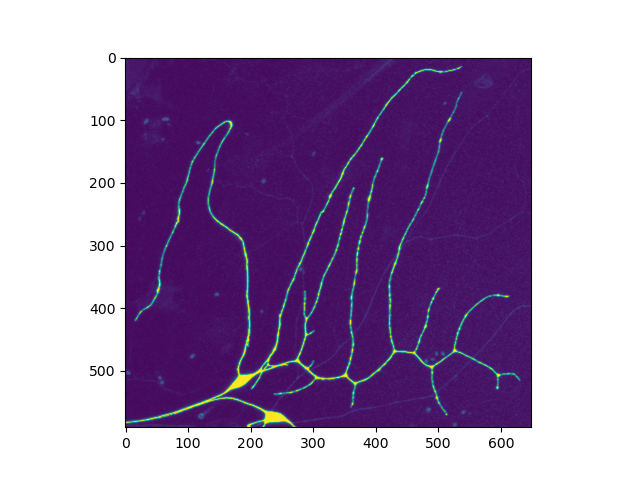

In [50]:
# plot the full tree and image
full_img_path = img_dir / (swc_path.stem + "_image.tif")
full_img = tf.imread(full_img_path)
if full_img.dtype != np.float32:
    full_img = full_img.astype(np.float32) / 255.0
plt.close('all')
fig = plt.figure()
plt.imshow(full_img.max(axis=0), vmin=0, vmax=1)
plt.show()

In [31]:
sections, _ = load.parse_swc(swc_list, verbose=False, transpose=False)
plot_sections(sections)

In [58]:
len(sub_images)

4

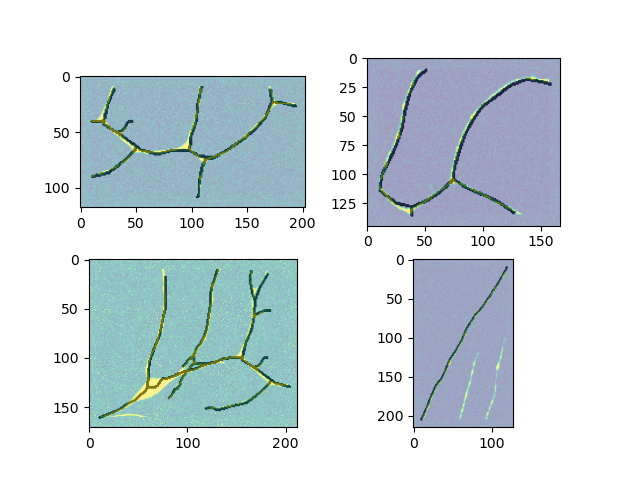

In [75]:
# plot subimages with skeletons
fig, axes = plt.subplots(2, int(np.ceil(len(sub_images)/2)))
i = 0
for sub_img, mask in zip(sub_images, masks):
    if 'float' not in str(sub_img.dtype):
        sub_img = sub_img / 255.0
    ax = axes.flatten()[i]
    ax.imshow(sub_img.amax(axis=0), vmin=0, vmax=1)
    ax.imshow(mask.data[0].amax(axis=0), alpha=0.5, cmap='Greys', vmin=0, vmax=1)
    i += 1


In [72]:
# plot the skeltons
for subtree in shifted_subtrees:
    sections, _ = load.parse_swc(subtree, verbose=False, transpose=False)
    plot_sections(sections)